### 설치된 라이브러리 버전 확인

In [1]:
import sys, platform
from importlib.metadata import version, PackageNotFoundError

def get_ver(pkg: str) -> str:
    try:
        return version(pkg)
    except PackageNotFoundError:
        return "not installed"

print("Python:", sys.version.split()[0])
print("OS:", platform.platform())
print("langgraph:", get_ver("langgraph"))
print("openai:", get_ver("openai"))
print("typing_extensions:", get_ver("typing_extensions"))

Python: 3.11.9
OS: macOS-14.6.1-x86_64-i386-64bit
langgraph: 1.0.4
openai: 2.8.1
typing_extensions: 4.15.0


### OpenAI API 사용

In [2]:
# 1) 루트 폴더에 .env 파일을 만들고 아래처럼 키를 적어둡니다.
#    OPENAI_API_KEY=sk-********************************
# 2) 필요시 설치: uv add python-dotenv openai

import os
from dotenv import load_dotenv
from openai import OpenAI

# .env 로딩
_ = load_dotenv()  # 기본적으로 현재 작업 디렉터리의 .env 탐색

# 환경변수에서 키 읽기 (dotenv가 주입)
api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    raise RuntimeError(
        "환경변수 OPENAI_API_KEY가 없습니다. 프로젝트 루트에 .env 파일을 만들고 "
        "OPENAI_API_KEY=... 값을 넣은 뒤 다시 실행하세요."
    )

# OpenAI 기본 클라이언트 (공식 엔드포인트 사용, base_url 불필요)
client = OpenAI(api_key=api_key)

# 사용할 모델 (필요시 변경)
DEFAULT_MODEL = "gpt-4o-mini"

def chat_local(prompt: str, model: str = None, temperature: float = 0.2) -> str:
    """
    기존 노트북의 chat_local 함수를 OpenAI API 호출로 대체합니다.
    다른 셀 코드는 수정 없이 그대로 사용 가능합니다.
    """
    model = model or DEFAULT_MODEL
    resp = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=temperature,
    )
    return (resp.choices[0].message.content or "").strip()

# 스모크 테스트
print(chat_local("한 줄로 인사해줘"))

안녕하세요! 오늘도 좋은 하루 되세요!


### Hello LangGraph

In [3]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

In [4]:
class S1(TypedDict):
    input: str      # key나 값을 입력하는 것이 아닌 어떤 데이터가 들어갈것인지 전달
    output: str

g1 = StateGraph(S1)

In [5]:
# 노드에서 사용할 에이전트
def echo_node(state: S1) -> S1:
    return {    # return 값은 state를 업데이트!
        "output": f"Echo: {state['input']}"
    } 

In [6]:
# 노드 생성
g1.add_node("echo", echo_node)

# 엣지 연결 생성
g1.add_edge(START, "echo")
g1.add_edge("echo", END)

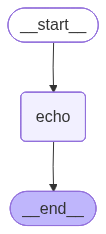

In [7]:
# Graph Compile -> 유효성 검사
app1 = g1.compile()

app1 # 그래프 출력

In [8]:
# invoke로 값 입력 후 실행
app1.invoke({"input": "LangGraph 첫 그래프!"})

{'input': 'LangGraph 첫 그래프!', 'output': 'Echo: LangGraph 첫 그래프!'}